# Modul 11 — Analisis Jaringan (NetworkX)
## Convergeni Data Consulting (CDC) — Klien: PT Komponen Jaya

Notebook ini menjalankan analisis jaringan pemasok Modul 11: graf 43 node,
degree dan betweenness centrality, dan simulasi kegagalan pemasok berdegree
1 versus berdegree 3.

## Membangun Graf dan Menghitung Centrality

In [1]:
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt

np.random.seed(42)
pabrik = ["Pabrik Cikarang", "Pabrik Karawang", "Pabrik Bekasi"]
pemasok = [f"Pemasok-{i:02d}" for i in range(1, 41)]

G = nx.Graph()
G.add_nodes_from(pabrik, tipe="pabrik")
G.add_nodes_from(pemasok, tipe="pemasok")
for p in pemasok:
    n_pabrik_dilayani = np.random.choice([1, 2, 3], p=[0.65, 0.25, 0.10])
    pabrik_terpilih = np.random.choice(pabrik, size=n_pabrik_dilayani, replace=False)
    for pb in pabrik_terpilih:
        G.add_edge(p, pb)

derajat = dict(G.degree())
antara = nx.betweenness_centrality(G)
print(f"|V|={G.number_of_nodes()}, |E|={G.number_of_edges()}")
print("Top 5 betweenness:", sorted(antara.items(), key=lambda x: -x[1])[:5])

|V|=43, |E|=51
Top 5 betweenness: [('Pabrik Cikarang', 0.5252129307007356), ('Pabrik Bekasi', 0.4603174603174603), ('Pabrik Karawang', 0.4569783197831978), ('Pemasok-16', 0.1343399148277197), ('Pemasok-26', 0.1343399148277197)]


## Visualisasi 1: Peta Jaringan Pemasok (Asset Baru, mengganti M11-01)

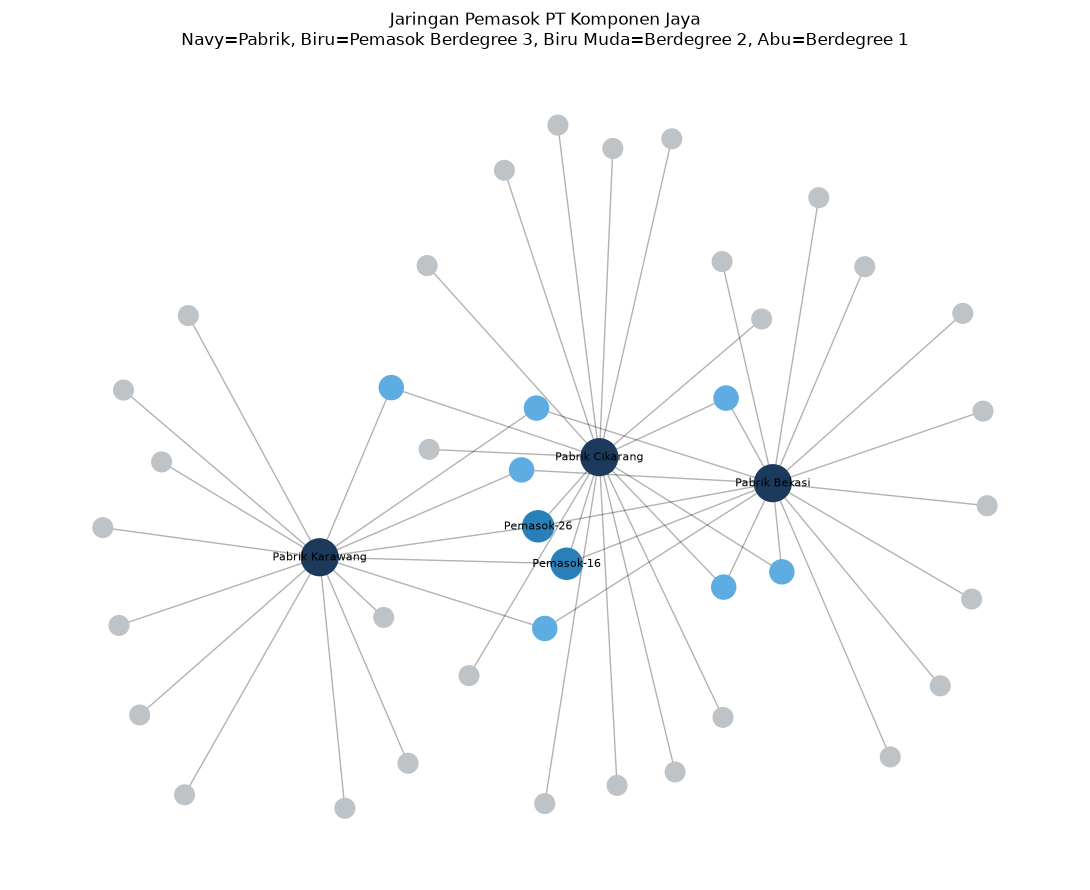

In [2]:
pos = nx.spring_layout(G, seed=42, k=0.4)

fig, ax = plt.subplots(figsize=(11, 9))
warna_node = []
ukuran_node = []
for node in G.nodes():
    if node in pabrik:
        warna_node.append("#1B3A5C")
        ukuran_node.append(700)
    elif derajat[node] >= 3:
        warna_node.append("#2980B9")   # pemasok berdegree 3 (Pemasok-16, Pemasok-26)
        ukuran_node.append(500)
    elif derajat[node] == 2:
        warna_node.append("#5DADE2")
        ukuran_node.append(300)
    else:
        warna_node.append("#BDC3C7")   # pemasok berdegree 1, mayoritas
        ukuran_node.append(200)

nx.draw_networkx_edges(G, pos, alpha=0.3, ax=ax)
nx.draw_networkx_nodes(G, pos, node_color=warna_node, node_size=ukuran_node, ax=ax)
label_penting = {n: n for n in list(pabrik) + [k for k, v in derajat.items() if v >= 3]}
nx.draw_networkx_labels(G, pos, labels=label_penting, font_size=8, ax=ax)
ax.set_title("Jaringan Pemasok PT Komponen Jaya\nNavy=Pabrik, Biru=Pemasok Berdegree 3, Biru Muda=Berdegree 2, Abu=Berdegree 1")
ax.axis("off")
plt.tight_layout()
plt.savefig("modul11_peta_jaringan.png", dpi=150, bbox_inches="tight")
plt.show()

## Visualisasi 2: Simulasi Kegagalan Pemasok Degree 1 vs Degree 3 (Asset Baru, mengganti M11-02)

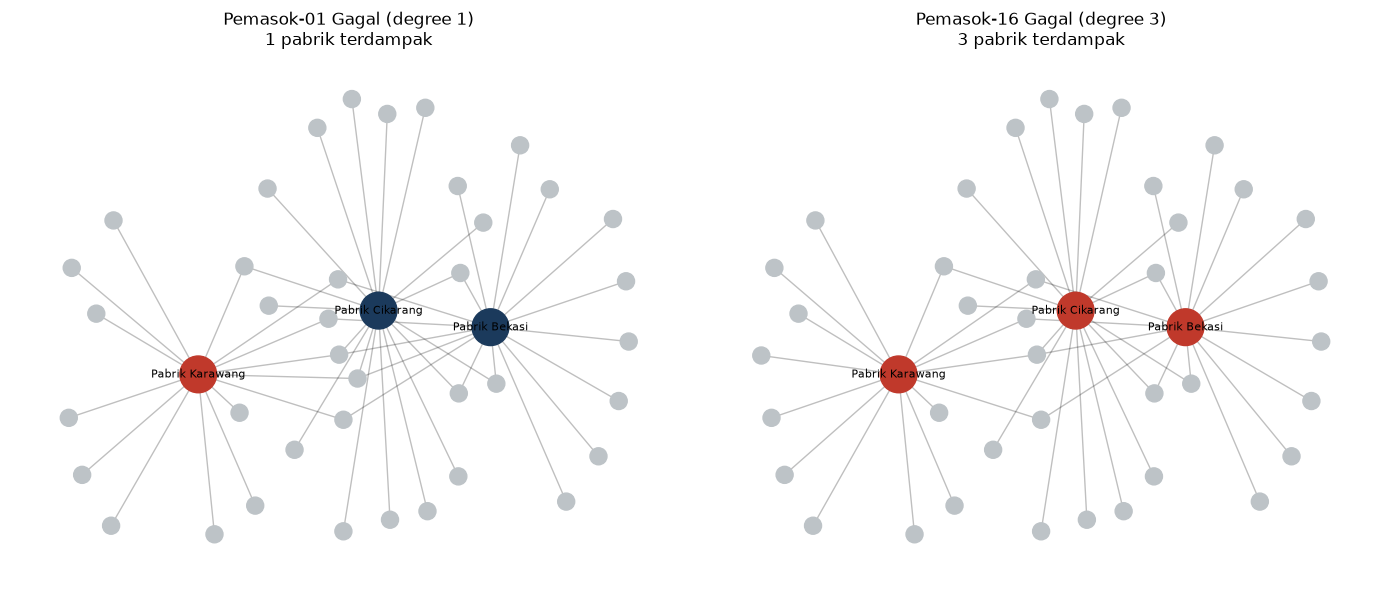

Pemasok-01 (degree 1) melayani: ['Pabrik Karawang']
Pemasok-16 (degree 3) melayani: ['Pabrik Bekasi', 'Pabrik Cikarang', 'Pabrik Karawang']


In [3]:
pemasok_degree1 = [p for p in pemasok if derajat[p] == 1][0]   # contoh representatif
pemasok_degree3 = "Pemasok-16"

G_tanpa_d1 = G.copy(); G_tanpa_d1.remove_node(pemasok_degree1)
G_tanpa_d3 = G.copy(); G_tanpa_d3.remove_node(pemasok_degree3)

def hitung_terdampak(G_asli, node_dihapus):
    return sorted(set(G_asli.neighbors(node_dihapus)) & set(pabrik))

terdampak_d1 = hitung_terdampak(G, pemasok_degree1)
terdampak_d3 = hitung_terdampak(G, pemasok_degree3)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for ax, G_sisa, node_hilang, terdampak, judul in [
    (axes[0], G_tanpa_d1, pemasok_degree1, terdampak_d1, f"{pemasok_degree1} Gagal (degree 1)\n{len(terdampak_d1)} pabrik terdampak"),
    (axes[1], G_tanpa_d3, pemasok_degree3, terdampak_d3, f"{pemasok_degree3} Gagal (degree 3)\n{len(terdampak_d3)} pabrik terdampak"),
]:
    warna = ["#C0392B" if n in terdampak else ("#1B3A5C" if n in pabrik else "#BDC3C7") for n in G_sisa.nodes()]
    ukuran = [700 if n in pabrik else 150 for n in G_sisa.nodes()]
    nx.draw_networkx_edges(G_sisa, pos, alpha=0.25, ax=ax)
    nx.draw_networkx_nodes(G_sisa, pos, node_color=warna, node_size=ukuran, ax=ax)
    nx.draw_networkx_labels(G_sisa, pos, labels={n: n for n in pabrik}, font_size=8, ax=ax)
    ax.set_title(judul)
    ax.axis("off")

plt.tight_layout()
plt.savefig("modul11_simulasi_kegagalan.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"{pemasok_degree1} (degree 1) melayani: {terdampak_d1}")
print(f"{pemasok_degree3} (degree 3) melayani: {terdampak_d3}")